In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All imports successful")

All imports successful


In [3]:
df = pd.read_csv("../data/raw/insurance.csv")

# Fix missing values same as EDA
df['age'].fillna(df['age'].median(), inplace=True)
df['bmi'].fillna(df['bmi'].median(), inplace=True)

print("Shape:", df.shape)
df.head()

Shape: (15000, 13)


,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7


In [4]:
le = LabelEncoder()

text_columns = ['sex', 'hereditary_diseases', 'city', 'job_title']

for col in text_columns:
    df[col] = le.fit_transform(df[col])

print("Done. Sample:")
df.head()

Done. Sample:


,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,1,64,24.3,8,1,0,55,72,0,0,2,13112.6
1,49.0,0,75,22.6,8,1,0,5,78,1,1,16,9567.0
2,32.0,0,64,17.8,4,2,1,63,88,1,1,0,32734.2
3,61.0,0,53,36.4,8,1,1,64,72,1,0,10,48517.6
4,19.0,0,50,20.6,8,0,0,8,82,1,0,22,1731.7


In [5]:
X = df.drop('claim', axis=1)
y = df['claim']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 12000
Testing rows: 3000


In [6]:
model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)
print("Model trained!")

Model trained!


In [7]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: ${mae:,.0f}")
print(f"R² Score: {r2:.3f}")

Mean Absolute Error: $1,053
R² Score: 0.960


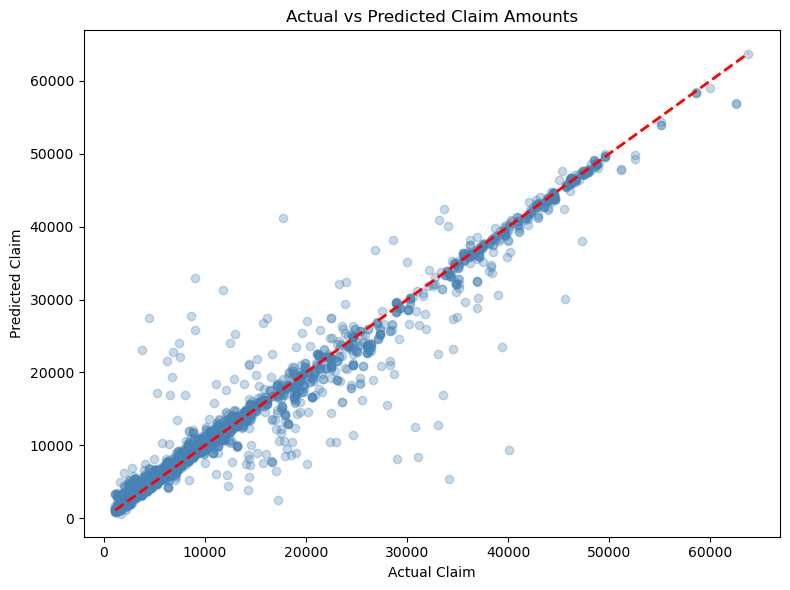

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2)
plt.xlabel('Actual Claim')
plt.ylabel('Predicted Claim')
plt.title('Actual vs Predicted Claim Amounts')
plt.tight_layout()
plt.show()

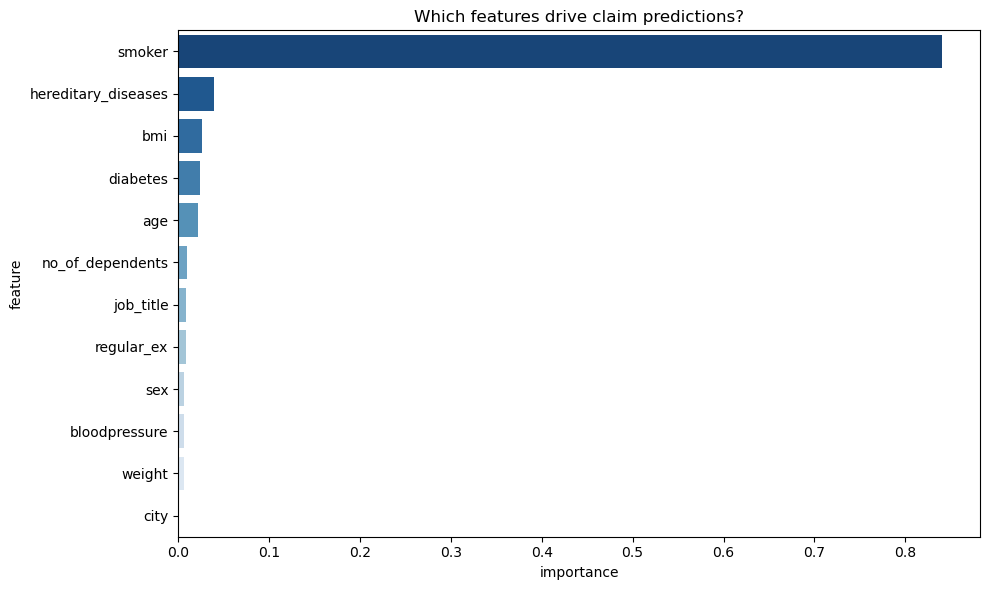

In [9]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance, x='importance', y='feature', palette='Blues_r')
plt.title('Which features drive claim predictions?')
plt.tight_layout()
plt.show()

In [10]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

print("SHAP values calculated!")

SHAP values calculated!


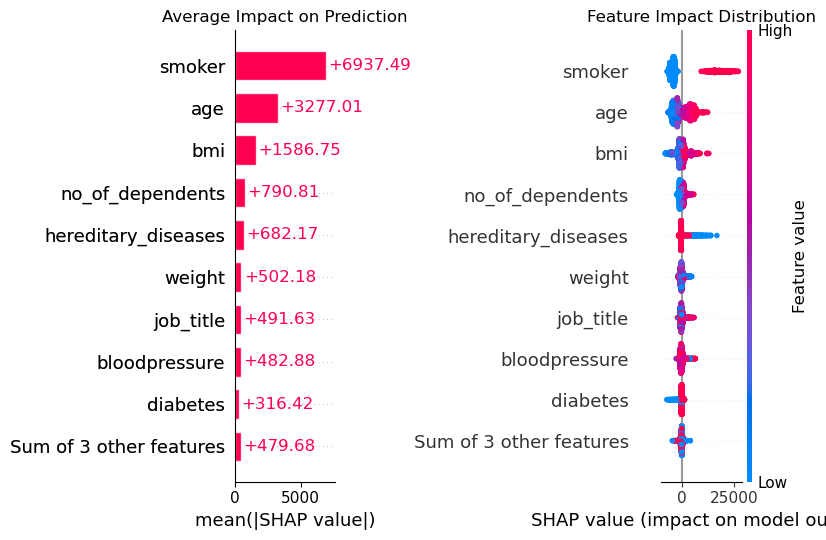

SHAP charts saved!


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 - Feature importance bar
plt.subplot(1, 2, 1)
shap.plots.bar(shap_values, show=False)
plt.title("Average Impact on Prediction")

# Chart 2 - Beeswarm
plt.subplot(1, 2, 2)
shap.plots.beeswarm(shap_values, show=False)
plt.title("Feature Impact Distribution")

plt.tight_layout()
plt.savefig("../data/shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("SHAP charts saved!")

In [12]:
import joblib

# Save the model
joblib.dump(model, "../src/model.pkl")
print("Model saved to src/model.pkl")

Model saved to src/model.pkl


In [13]:
# Save cleaned data to processed folder
df.to_csv("../data/processed/insurance_cleaned.csv", index=False)
print("Cleaned data saved!")
print("Shape:", df.shape)

Cleaned data saved!
Shape: (15000, 13)
